# Jerome Avenue rezoning — building-level (BIN) table

The earlier Jerome work is *lot-level* (one row per BBL). But the 2018 rezoning changed
what got **built**, so here we drop down to individual buildings — one row per **BIN**
(Building Identification Number).

Flow: official rezoning lots -> BBLs (kept as strings) -> PLUTO attributes incl. address,
building class, and residential units (record which BBLs are missing) -> **recover retired lots
through PLUTO's `APPBBL` apportionment lineage** -> the BINs + footprint geometry on those lots
(pulled *only* for our BBLs, never the whole ~1M-row footprint set) -> DOB job filings as a
secondary check on the apartment flag.

The `APPBBL` step (§2b) matters more than its size suggests. When DOF retires a lot the footprint
layer keeps mapping the standing building to the *old* `base_bbl`, so the BIN survives with no
attributes — silently counted as "not an apartment" with zero units. On this corridor that
orphaned exactly one BIN, and it happens to be the largest new building on Jerome Avenue.

Two things were tested and deliberately **not** used, documented in the audit cells §3b and §6b:
the historic footprint layer `ipkp-snf6` recovers no standing buildings here, and the 2017
MapPLUTO extract is used only as *evidence* about lots with no building — never to backfill
attributes, because for a redeveloped lot it returns the pre-demolition state.

**Apartment / unit counts come from PLUTO** (the assessor's building class + `unitsres`),
which is authoritative; DOB filings are carried alongside only to corroborate. Note
`unitsres` is lot-level, so on the handful of lots with more than one building the units
are not split per building.

The last two sections answer the question the table was built for:

- **§6c — demolition audit.** The footprint layer keeps a *live* row after DOB signs off a
  demolition, so a torn-down building can be counted as housing that exists. Three
  independent sources are checked per BIN and each signal is **classified** rather than
  dropped (`gone` / `rebuilt` / `standing` / `pending`), because most demolitions here are a
  teardown *followed by a new building on the same BIN* — including the corridor's largest.
- **§8 — residential units built since 2000**, counted **per lot** (never per BIN, which
  would double-count) and excluding the buildings that are actually gone.

Sparse by design, with a few sanity-check prints along the way.

In [1]:
from pathlib import Path

import pandas as pd
import requests
import geopandas as gpd

DOMAIN = "data.cityofnewyork.us"


def soda(dataset_id, params):
    """Query a Socrata dataset (anonymous) and return a DataFrame."""
    url = f"https://{DOMAIN}/resource/{dataset_id}.json"
    r = requests.get(url, params=params, timeout=300)
    r.raise_for_status()
    return pd.DataFrame(r.json())


def in_clause(values):
    """Build a SoQL IN-clause string from an iterable, e.g. 'a','b','c'."""
    return "'" + "','".join(values) + "'"


def soda_in(dataset_id, select, field, values, batch=250, extra=None):
    """Query `dataset_id` for `field in (values)`, chunked to beat URL-length limits."""
    values = list(dict.fromkeys(values))
    out = []
    for i in range(0, len(values), batch):
        where = f"{field} in ({in_clause(values[i:i + batch])})"
        if extra:
            where = f"{extra} AND {where}"
        chunk = soda(dataset_id, {"$select": select, "$where": where, "$limit": "200000"})
        if len(chunk):
            out.append(chunk)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def bbl_str(s):
    """Socrata returns BBLs float-formatted (2024890005.00000000); keep them 10-char strings."""
    return s.astype(str).str.split(".").str[0]

## 1. Ground truth: the official rezoning lots -> BBLs
BBL = borough (2 = Bronx) + block (5-digit) + lot (4-digit), kept as a **string** — a
10-digit BBL cast to float loses its identity.

In [2]:
lots = pd.read_csv("../data/raw/jerome_rezone_db.csv")
bbls = ("2" + lots["Block"].astype(str).str.zfill(5)
        + lots["Lot"].astype(str).str.zfill(4)).unique().tolist()
print("rezoned lots:", len(lots), "| unique BBLs:", len(bbls), "| e.g.", bbls[:3])

rezoned lots: 188 | unique BBLs: 188 | e.g. ['2024890005', '2024890006', '2024890008']


## 2. PLUTO attributes, and which BBLs are missing
We grab the address, building class, year built, residential/total units and building
count. PLUTO returns `bbl` float-formatted (`2024890005.00000000`); split off the decimal
to keep it a clean 10-char string. We chunk the IN-clause to stay under Socrata's URL limit.

In [3]:
PLUTO_COLS = "bbl,address,bldgclass,landuse,yearbuilt,unitsres,unitstotal,numbldgs,assesstot"


def get_pluto(bbls, batch_size=500):
    out = []
    for i in range(0, len(bbls), batch_size):
        chunk = soda("64uk-42ks", {
            "$select": PLUTO_COLS,
            "$where": f"bbl in ({in_clause(bbls[i:i + batch_size])})",
            "$limit": "100000",
        })
        chunk["bbl"] = chunk["bbl"].astype(str).str.split(".").str[0]  # keep as string
        out.append(chunk)
    return pd.concat(out, ignore_index=True)


pluto = get_pluto(bbls)
pluto["attr_source"] = "pluto_current"

missing_bbls = sorted(set(bbls) - set(pluto["bbl"]))
print("PLUTO matched:", len(pluto), "of", len(bbls), "| missing:", len(missing_bbls))
print("missing BBLs:", missing_bbls)

PLUTO matched: 180 of 188 | missing: 8
missing BBLs: ['2028530015', '2028560053', '2028570023', '2028620097', '2028650019', '2028710106', '2028710115', '2028710140']


## 2b. Recover retired lots through PLUTO's apportionment lineage (`APPBBL`)
A lot that DOF has **retired** — split, merged, or converted to a condo — drops out of current
PLUTO, but the footprint layer keeps mapping the standing building to the *old* `base_bbl`. That
asymmetry is what orphans a BIN: real building, no attributes.

`APPBBL` closes the gap. It lives on the **successor** row and points *back* at the lot it was
created from, so we ask "which current lot declares one of our missing BBLs as its `appbbl`?"
Two guards, because a wrong value that looks authoritative is worse than a NaN: we refuse to
guess when a retired lot has **more than one** successor, and we skip a successor that is already
mapped on a BIN of its own (reusing its attributes there would count the same units twice).

This is a narrow instrument — it repairs attributes on BINs we already have and **never adds a
row**. `attr_source` records where every row's attributes came from.

In [4]:
succ = soda_in("64uk-42ks", PLUTO_COLS + ",appbbl,appdate", "appbbl", missing_bbls)

recovered = []
if len(succ):
    succ["bbl"], succ["appbbl"] = bbl_str(succ["bbl"]), bbl_str(succ["appbbl"])
    succ = succ[succ["appbbl"].isin(missing_bbls)]

    succ_fp = soda_in("5zhs-2jue", "base_bbl,bin", "base_bbl", succ["bbl"].tolist())
    has_own_fp = set(bbl_str(succ_fp["base_bbl"])) if len(succ_fp) else set()
    n_succ = succ.groupby("appbbl")["bbl"].nunique()
    already = set(pluto["bbl"])

    for old, grp in succ.groupby("appbbl"):
        new = grp["bbl"].iloc[0]
        if n_succ[old] > 1:
            print(f"  skip {old}: {n_succ[old]} successors — ambiguous, left unmatched")
        elif new in already or new in has_own_fp:
            print(f"  skip {old} -> {new}: successor is already mapped on its own BIN")
        else:
            row = grp.iloc[0][PLUTO_COLS.split(",")].to_dict()
            row["bbl"] = old            # attach to the retired lot the footprint still points at
            row["attr_source"] = f"pluto_appbbl_{new}"
            recovered.append(row)

if recovered:
    pluto = pd.concat([pluto, pd.DataFrame(recovered)], ignore_index=True)

# coerce *after* the concat so recovered rows are numeric too
for c in ["yearbuilt", "unitsres", "unitstotal", "numbldgs", "assesstot"]:
    pluto[c] = pd.to_numeric(pluto[c], errors="coerce")   # bbl/address/bldgclass stay strings

print("APPBBL recovered:", len(recovered), "of", len(missing_bbls), "missing lots",
      "| still unmatched:", len(set(bbls) - set(pluto["bbl"])))
for r in recovered:
    print(f"  {r['bbl']} -> {r['attr_source'].rsplit('_', 1)[-1]} | {r['address']} | "
          f"{r['bldgclass']} | {r['unitsres']} res units")
print("PLUTO says # buildings on these lots (numbldgs sum):", int(pluto["numbldgs"].sum()))

APPBBL recovered: 1 of 8 missing lots | still unmatched: 7
  2028560053 -> 2028567501 | 1325 JEROME AVENUE | RM | 255 res units
PLUTO says # buildings on these lots (numbldgs sum): 178


## 3. Buildings (BINs) + footprint geometry — for these lots only
`$where base_bbl in (...)` keeps us from scanning the full footprint dataset. Each row is a
**building**, so one lot can yield several BINs — but on this corridor most lots have one
building and ~30 have none (they're vacant land, parking, or gas-station/garage sites, i.e.
the parcels the rezoning targeted for redevelopment). We carry the geometry along as WKT.

In [5]:
fp = soda("5zhs-2jue", {
    "$select": "base_bbl,bin,the_geom,construction_year,last_status_type",
    "$where": f"base_bbl in ({in_clause(bbls)})",
    "$limit": "20000",
})
fp["base_bbl"] = bbl_str(fp["base_bbl"])
fp["bin"] = fp["bin"].astype(str)
fp["construction_year"] = pd.to_numeric(fp["construction_year"], errors="coerce")

# GeoJSON -> geometry -> WKT string (tabular, no map)
_geom = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "geometry": g, "properties": {}} for g in fp["the_geom"]],
    crs="EPSG:4326",
).geometry
fp["the_geom_wkt"] = _geom.to_wkt().values
fp = fp.drop(columns="the_geom")

print("footprints (BINs):", len(fp),
      "| lots with a footprint:", fp["base_bbl"].nunique(), "of", len(bbls),
      "| lots with >1 building:", int((fp.groupby("base_bbl").size() > 1).sum()))
print("footprint status:", fp["last_status_type"].value_counts(dropna=False).to_dict())

footprints (BINs): 166 | lots with a footprint: 157 of 188 | lots with >1 building: 7
footprint status: {'Constructed': 163, nan: 2, 'Alteration': 1}


## 3b. Audit: does the *historic* footprint layer add any buildings? (answer: no)
`ipkp-snf6` is the archive of retired footprints. It looks like an obvious way to recover
buildings on lots the current layer has nothing for — so this cell settles the question in the
notebook rather than leaving it to be re-investigated.

The rule is: **keep a BIN only if it is still live in the current footprint layer.** Demolished
buildings are out of scope — this table is one row per *standing* building, and their lot-level
`unitsres` would be broadcast onto them and double-count units.

One trap worth knowing: BINs of the form `<boro>000000` (here `2000000`) are a **sentinel**
meaning "no BIN assigned", not a real building. Join on it and you silently pull in unrelated
buildings from across the borough — so it is dropped first.

If `net new BINs` is ever non-zero on a future run, this conclusion needs revisiting.

In [6]:
hist = soda_in("ipkp-snf6", "base_bbl,bin,construction_year,demolition_year,last_status_type",
               "base_bbl", bbls)
if len(hist):
    hist["base_bbl"], hist["bin"] = bbl_str(hist["base_bbl"]), hist["bin"].astype(str)
    sentinel = hist["bin"].str.fullmatch(r"\d000000")
    live = set(fp["bin"])
    kept = hist.loc[~sentinel & hist["bin"].isin(live), "bin"]
    print("historic BINs on rezoned lots:", hist["bin"].nunique())
    print("  sentinel (<boro>000000) dropped:", hist.loc[sentinel, "bin"].nunique())
    print("  demolished-only, excluded by the rule:",
          hist.loc[~sentinel & ~hist["bin"].isin(live), "bin"].nunique())
    print("  already in the current table:", kept.nunique())
    print("net new BINs:", len(set(kept) - live))   # by construction 0; a non-zero means revisit

historic BINs on rezoned lots: 30
  sentinel (<boro>000000) dropped: 1
  demolished-only, excluded by the rule: 25
  already in the current table: 4
net new BINs: 0


## 4. Attach PLUTO to each BIN
PLUTO is lot-level, so its attributes are copied onto every BIN sharing that lot. We keep
both year fields — PLUTO `yearbuilt` and footprint `construction_year` — since they can
disagree.

In [7]:
bins = fp.merge(pluto, left_on="base_bbl", right_on="bbl", how="left").drop(columns="bbl")
bins["attr_source"] = bins["attr_source"].fillna("none")
print("BIN rows:", len(bins), "| BINs with no PLUTO match:", int(bins["bldgclass"].isna().sum()))
print("attribute source:", bins["attr_source"].value_counts().to_dict())

BIN rows: 166 | BINs with no PLUTO match: 0
attribute source: {'pluto_current': 165, 'pluto_appbbl_2028567501': 1}


## 5. Is the building an apartment, and how many units? (PLUTO-primary)
Assessor building class is the authoritative signal: **C = walk-up apartments,
D = elevator apartments**; classes like S (mixed residential/commercial) are caught by the
unit threshold. `res_units` is PLUTO `unitsres` (residential units on the lot).

In [8]:
bins["res_units"] = bins["unitsres"]
bins["is_apartment"] = (bins["bldgclass"].fillna("").str[0].isin(["C", "D"])
                        | (bins["res_units"] >= 3))
print("apartment BINs (PLUTO):", int(bins["is_apartment"].sum()), "of", len(bins),
      "| total residential units:", int(bins["res_units"].fillna(0).sum()))

apartment BINs (PLUTO): 27 of 166 | total residential units: 1590


## 6. DOB job filings — apartment cross-check **and the dates**
DOB filings are keyed on BIN. We use two sources because DOB switched systems: the legacy
**BIS** dataset (`ic3t-wcy2`) covers older jobs, and **DOB NOW** (`w9ak-ipjd`) covers newer
ones (post-~2021) — so the rezoning-era buildings only appear in DOB NOW. Occupancy in BIS
mixes the old 1968 code (**J-2** = multiple dwelling) and newer codes (**R-2** = apartments)
and corroborates the apartment flag. For the *dates*, we take each BIN's **New Building**
filing across both systems: `dob_nb_filed` = when the new apartments were *expected* (first
NB filing) and `dob_nb_signoff` = when DOB signed the building off. Read these next to PLUTO
`yearbuilt` (the year the assessor recorded it as built).

In [9]:
APT_OCC = {"J-2", "R-2"}
bin_list = fp["bin"].unique().tolist()

# --- legacy BIS filings (occupancy + older dates) ---
dob = soda("ic3t-wcy2", {
    "$select": ("bin__,job_type,proposed_occupancy,existing_occupancy,"
                "proposed_dwelling_units,existing_dwelling_units,"
                "pre__filing_date,signoff_date"),
    "$where": f"bin__ in ({in_clause(bin_list)})",
    "$limit": "50000",
})
for c in ["proposed_dwelling_units", "existing_dwelling_units"]:
    dob[c] = pd.to_numeric(dob[c], errors="coerce")
for c in ["pre__filing_date", "signoff_date"]:
    dob[c] = pd.to_datetime(dob[c], format="%m/%d/%Y", errors="coerce")  # BIS dates are m/d/Y

apt_occ = dob["proposed_occupancy"].isin(APT_OCC) | dob["existing_occupancy"].isin(APT_OCC)
apt_units = dob[["proposed_dwelling_units", "existing_dwelling_units"]].max(axis=1) >= 3
dob["is_apt_filing"] = apt_occ | apt_units

nb_bis = (dob[dob["job_type"] == "NB"]
          .rename(columns={"bin__": "bin", "pre__filing_date": "filed", "signoff_date": "signoff"})
          [["bin", "filed", "signoff"]])

# --- DOB NOW New-Building filings (where the recent buildings live) ---
now = soda("w9ak-ipjd", {
    "$select": "bin,filing_date,signoff_date",
    "$where": f"job_type='New Building' AND bin in ({in_clause(bin_list)})",
    "$limit": "50000",
})
now["bin"] = now["bin"].astype(str)
now = now.rename(columns={"filing_date": "filed", "signoff_date": "signoff"})
for c in ["filed", "signoff"]:
    now[c] = pd.to_datetime(now[c], errors="coerce")   # DOB NOW dates are ISO

# combine both systems: earliest NB filing, latest NB sign-off per BIN
nb = (pd.concat([nb_bis, now[["bin", "filed", "signoff"]]], ignore_index=True)
      .groupby("bin").agg(dob_nb_filed=("filed", "min"), dob_nb_signoff=("signoff", "max"))
      .reset_index())

dob_bin = dob.groupby("bin__").agg(
    dob_is_apartment=("is_apt_filing", "any"),
    dob_dwelling_units=("proposed_dwelling_units", "max"),
    dob_first_filed=("pre__filing_date", "min"),
    n_dob_filings=("is_apt_filing", "size"),
).reset_index().rename(columns={"bin__": "bin"})

bins = (bins.merge(dob_bin, on="bin", how="left")
             .merge(nb, on="bin", how="left"))
bins["has_dob_record"] = bins["n_dob_filings"].notna()
bins["dob_is_apartment"] = bins["dob_is_apartment"].fillna(False)

agree = (bins["is_apartment"] == bins["dob_is_apartment"]).mean()
print("BINs with a DOB filing:", int(bins["has_dob_record"].sum()), "of", len(bins),
      "| PLUTO vs DOB apartment flags agree:", f"{agree:.0%}")
print("BINs with a New-Building filing date (BIS + DOB NOW):",
      int(bins["dob_nb_filed"].notna().sum()))

BINs with a DOB filing: 130 of 166 | PLUTO vs DOB apartment flags agree: 89%
BINs with a New-Building filing date (BIS + DOB NOW): 22


## 6b. Audit: the lots with no building at all
~31 of the 188 lots have no footprint in either layer, so they never reach this table. That is
mostly the *right* answer rather than a data gap, and the 2017 Bronx MapPLUTO extract
(`BX2017V1.csv`, the vintage just before the rezoning) shows why: they are overwhelmingly
**G**-class garages and gas stations and **V**-class vacant land — precisely the auto-oriented
parcels the rezoning targeted for redevelopment.

The exception worth watching is any **C**-class (walk-up apartment) lot: an apartment building
with no footprint is a genuine missing record, not an empty lot.

2017 MapPLUTO is the DCP BYTES download, not the Socrata schema — columns are TitleCase and the
string fields are space-padded fixed-width, so everything gets stripped. This cell is
**print-only**; it deliberately adds no rows, and 2017 values never overwrite current data.

In [10]:
P17 = ["BBL", "Address", "BldgClass", "LandUse", "YearBuilt", "UnitsRes", "NumBldgs"]
p17 = pd.read_csv("../data/raw/BX2017V1.csv", usecols=P17, dtype=str, low_memory=False)
for c in P17:
    p17[c] = p17[c].str.strip()                 # BYTES pads to fixed width

unresolved = sorted(set(bbls) - set(fp["base_bbl"]))
u17 = p17[p17["BBL"].isin(unresolved)]
CLASS = {"G": "garage / gas station", "V": "vacant land", "Z": "misc",
         "C": "walk-up apartment  <- data gap, not an empty lot",
         "K": "store", "F": "factory / warehouse", "Q": "outdoor recreation"}
print("lots with no footprint:", len(unresolved), "| found in 2017 PLUTO:", len(u17))
for letter, n in u17["BldgClass"].str[0].value_counts().items():
    print(f"  {letter}  {CLASS.get(letter, '?'):40s} {n:3d}")
print("auto-oriented or vacant (G/V):",
      int(u17["BldgClass"].str[0].isin(["G", "V"]).sum()), "of", len(u17))

lots with no footprint: 31 | found in 2017 PLUTO: 31
  G  garage / gas station                      15
  V  vacant land                                7
  Z  misc                                       4
  C  walk-up apartment  <- data gap, not an empty lot   2
  K  store                                      1
  F  factory / warehouse                        1
  Q  outdoor recreation                         1
auto-oriented or vacant (G/V): 22 of 31


## 6c. Demolition audit — are any of these buildings gone?
The current footprint layer keeps a **live** row after DOB signs off a demolition, so a
torn-down building can sit in this table with its old attributes and be counted as housing
that exists. Three independent sources are checked per BIN:

- **`ipkp-snf6`** — the historic footprint archive (every row is a demolition; carries
  `demolition_year`).
- **BIS `ic3t-wcy2`** — legacy demolition jobs, `job_type = 'DM'`.
- **DOB NOW `w9ak-ipjd`** — `job_type = 'Full Demolition'`.

A demolition signal is **not** the same as "this row is dead", so BINs are classified rather
than dropped. The DOB **sign-off date** is the demolition event; the archive's
`demolition_year` is an annual snapshot that lags it (on this corridor by ~2 years), so the
archive is used only where DOB has no record.

- **`gone`** — demolition completed and PLUTO now shows vacant land (class `V`) or no lot at
  all. The footprint row is stale; the building is not there.
- **`rebuilt`** — demolition completed but the building on record postdates it
  (`yearbuilt` >= demolition year): the old building came down, a new one went up on the same
  BIN. **Standing** — these must be kept. The largest new building on the corridor is one.
- **`standing`** — demolition completed yet PLUTO still shows an *older* building: a partial
  demolition, an accessory structure, or a stale record. Flagged for review, not excluded.
- **`pending`** — a demolition filed with no sign-off; it is coming down now.

Nothing is deleted. The audit adds `demo_status`, `demo_year` and `demo_source`.

In [11]:
# --- source 1: historic footprint archive (annual, lags the actual event) ---
arch = soda_in("ipkp-snf6", "bin,demolition_year", "bin", bin_list)
arch_year = pd.Series(dtype=float)
if len(arch):
    arch = arch[~arch["bin"].astype(str).str.fullmatch(r"\d000000")]   # sentinel, not a building
    arch_year = (pd.to_numeric(arch["demolition_year"], errors="coerce")
                 .groupby(arch["bin"].astype(str)).max())

# --- source 2: legacy BIS demolition jobs ---
bis_dm = soda_in("ic3t-wcy2", "bin__,job_status_descrp,pre__filing_date,signoff_date",
                 "bin__", bin_list, extra="job_type='DM'")
# --- source 3: DOB NOW full demolitions ---
now_dm = soda_in("w9ak-ipjd", "bin,filing_date,signoff_date", "bin", bin_list,
                 extra="job_type='Full Demolition'")

# normalise both DOB systems to (bin, signoff) — BIS dates are m/d/Y, DOB NOW is ISO
dob_dm = []
if len(bis_dm):
    bis_dm["signoff"] = pd.to_datetime(bis_dm["signoff_date"], format="%m/%d/%Y", errors="coerce")
    dob_dm.append(bis_dm.rename(columns={"bin__": "bin"})[["bin", "signoff"]])
if len(now_dm):
    now_dm["signoff"] = pd.to_datetime(now_dm["signoff_date"], errors="coerce")
    dob_dm.append(now_dm.assign(bin=now_dm["bin"].astype(str))[["bin", "signoff"]])
dob_dm = pd.concat(dob_dm, ignore_index=True) if dob_dm else pd.DataFrame(columns=["bin", "signoff"])

dob_year = dob_dm.dropna(subset=["signoff"]).groupby("bin")["signoff"].max().dt.year
pending = set(dob_dm.loc[dob_dm["signoff"].isna(), "bin"])          # filed, never signed off

# DOB sign-off is authoritative; fall back to the archive year only where DOB is silent
bins["demo_year"] = bins["bin"].map(dob_year)
bins["demo_year"] = bins["demo_year"].fillna(bins["bin"].map(arch_year))

SRC = {"archive": set(arch_year.index), "dob": set(dob_dm["bin"])}
bins["demo_source"] = bins["bin"].map(
    lambda b: "+".join(k for k, v in SRC.items() if b in v) or "")

# the year the building on record was put up (PLUTO first, footprint as fallback)
built = bins["yearbuilt"].where(bins["yearbuilt"] > 0, bins["construction_year"])
vacant = bins["bldgclass"].isna() | bins["bldgclass"].fillna("").str.startswith("V")

bins["demo_status"] = "none"
done = bins["demo_year"].notna()
bins.loc[done & (built >= bins["demo_year"]), "demo_status"] = "rebuilt"
bins.loc[done & (built < bins["demo_year"]), "demo_status"] = "standing"
bins.loc[done & vacant & ~(built >= bins["demo_year"]), "demo_status"] = "gone"
bins.loc[bins["bin"].isin(pending) & (bins["demo_status"] == "none"), "demo_status"] = "pending"

print("demolition signals:", int((bins["demo_status"] != "none").sum()), "of", len(bins), "BINs")
print("demo_status:", bins["demo_status"].value_counts().to_dict())
flagged = bins[bins["demo_status"].isin(["gone", "pending", "standing"])]
if len(flagged):
    print("\nnot a standing replacement - review these:")
    print(flagged[["bin", "address", "bldgclass", "yearbuilt", "res_units",
                   "demo_year", "demo_status", "demo_source"]].to_string(index=False))
print("\nresidential units on 'gone' rows (excluded from the chart below):",
      int(bins.loc[bins["demo_status"] == "gone", "res_units"].fillna(0).sum()))

demolition signals: 7 of 166 BINs
demo_status: {'none': 159, 'rebuilt': 5, 'pending': 1, 'gone': 1}

not a standing replacement - review these:
    bin            address bldgclass  yearbuilt  res_units  demo_year demo_status demo_source
2008287 1342 INWOOD AVENUE        F5       1990          0        NaN     pending         dob
2008387 1959 JEROME AVENUE        V1          0          0     2025.0        gone         dob

residential units on 'gone' rows (excluded from the chart below): 0


## 7. Final BIN table + save

In [12]:
cols = ["bin", "base_bbl", "address", "construction_year", "yearbuilt", "bldgclass",
        "landuse", "is_apartment", "res_units", "unitstotal", "numbldgs", "assesstot",
        "dob_is_apartment", "dob_dwelling_units", "dob_first_filed", "dob_nb_filed",
        "dob_nb_signoff", "n_dob_filings", "has_dob_record", "last_status_type",
        "demo_status", "demo_year", "demo_source", "attr_source", "the_geom_wkt"]
bins = bins[cols]

# resolve so the destination is printed in full — this notebook must be run from notebooks/
OUT = Path("jerome_ave_bins.csv").resolve()
bins.to_csv(OUT, index=False)
print("saved:", bins.shape, "->", OUT)
print("apartment BINs:", int(bins["is_apartment"].sum()), "of", len(bins),
      "| residential units:", int(bins["res_units"].fillna(0).sum()))
bins.drop(columns="the_geom_wkt").head()

saved: (166, 25) -> C:\Users\arian\Documents\fable_housing\notebooks\jerome_ave_bins.csv
apartment BINs: 27 of 166 | residential units: 1590


,bin,base_bbl,address,construction_year,yearbuilt,bldgclass,landuse,is_apartment,res_units,unitstotal,...,dob_first_filed,dob_nb_filed,dob_nb_signoff,n_dob_filings,has_dob_record,last_status_type,demo_status,demo_year,demo_source,attr_source
0,2003006,2024890005,1220 JEROME AVENUE,1931.0,1931,M1,8,False,0,1,...,2020-12-15,NaT,NaT,2.0,True,Constructed,none,NaN,,pluto_current
1,2003007,2024890006,1222 JEROME AVENUE,1934.0,1934,K2,5,False,0,2,...,2014-06-10,NaT,NaT,1.0,True,Constructed,none,NaN,,pluto_current
2,2003008,2024890008,1230 JEROME AVENUE,1931.0,1931,K1,5,False,0,2,...,2000-01-24,NaT,NaT,12.0,True,Constructed,none,NaN,,pluto_current
3,2092378,2024890011,1234 JEROME AVENUE,1931.0,1931,G2,7,False,0,1,...,2001-08-31,NaT,NaT,2.0,True,Constructed,none,NaN,,pluto_current
4,2003009,2024890014,1240 JEROME AVENUE,1931.0,1931,G2,7,False,0,1,...,2012-07-23,NaT,NaT,1.0,True,Constructed,none,NaN,,pluto_current


## 8. Residential units built since 2000
The question the table was built for: how much housing actually arrived, and when?

Two things have to be right or the number is wrong:

1. **Units are counted per lot, not per BIN.** `res_units` is PLUTO `unitsres`, which is a
   **lot-level** figure copied onto every building on the lot — summing it across BINs
   double-counts the multi-building lots. So the chart frame is de-duplicated to one row per
   `base_bbl` (keeping the lot's newest building, which is the year the units arrived).
2. **`gone` buildings are excluded** (see §6c) — they no longer exist. `rebuilt`, `standing`
   and `pending` rows are kept: those buildings are standing today.

Year = PLUTO `yearbuilt`, falling back to the footprint's `construction_year` where PLUTO
records a 0. The **2018 rezoning** is marked so the pre/post split reads off the chart.

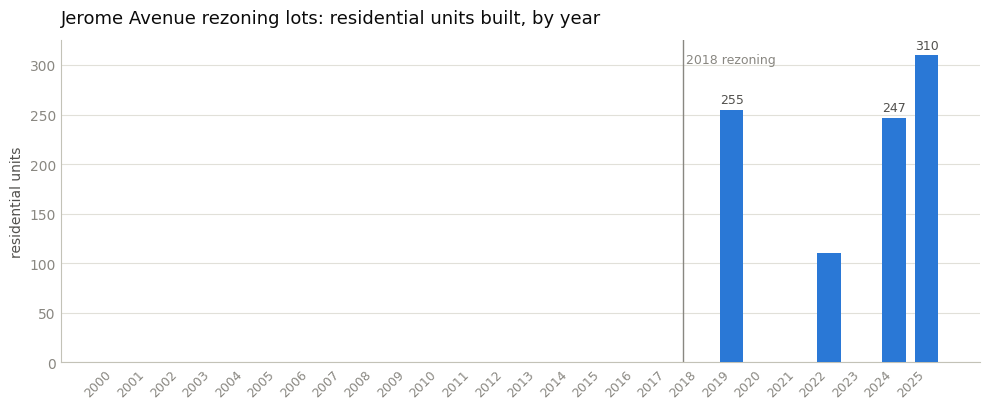

lots built 2000+: 21 | residential units: 922
  2000-2017 (pre-rezoning):  0 units
  2018+     (post-rezoning): 922 units on 11 lots


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# chart ink — recessive chrome, one categorical hue for a single series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES_1 = "#e1e0d9", "#c3c2b7", "#2a78d6"


def units_by_year(df, first=2000, last=None):
    """Residential units per year of construction, counted once per lot."""
    d = df[df["demo_status"] != "gone"].copy()
    d["built_year"] = d["yearbuilt"].where(d["yearbuilt"] > 0, d["construction_year"])
    d = d.dropna(subset=["built_year"])
    # lot-level units: keep the lot's newest building so units land on the redevelopment year
    d = d.sort_values("built_year", ascending=False).drop_duplicates("base_bbl")
    d = d[d["built_year"] >= first]
    if last is not None:
        d = d[d["built_year"] <= last]
    d["built_year"] = d["built_year"].astype(int)
    return d


REZONE_YEAR = 2018
built = units_by_year(bins)
years = range(2000, int(built["built_year"].max()) + 1)
units = built.groupby("built_year")["res_units"].sum().reindex(years, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(units.index, units.values, width=0.72, color=SERIES_1, zorder=3)

# rezoning marker, in chrome ink — it is context, not a series
ax.axvline(REZONE_YEAR - 0.5, color=MUTED, lw=1, zorder=2)
ax.text(REZONE_YEAR - 0.4, ax.get_ylim()[1] * 0.96, "2018 rezoning",
        color=MUTED, fontsize=9, va="top")

# direct-label only the years that carry the story
for yr in units.nlargest(3).index:
    ax.text(yr, units[yr] + units.max() * 0.02, f"{int(units[yr]):,}",
            ha="center", fontsize=9, color=INK2)

ax.set_title("Jerome Avenue rezoning lots: residential units built, by year",
             fontsize=13, color=INK, pad=12, loc="left")
ax.set_ylabel("residential units", fontsize=10, color=INK2)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xticks(list(years))
ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right", fontsize=9)
ax.tick_params(colors=MUTED, length=0)
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
fig.tight_layout()
plt.show()

pre = built.loc[built["built_year"] < REZONE_YEAR, "res_units"].sum()
post = built.loc[built["built_year"] >= REZONE_YEAR, "res_units"].sum()
print(f"lots built 2000+: {len(built)} | residential units: {int(built['res_units'].sum()):,}")
print(f"  2000-{REZONE_YEAR - 1} (pre-rezoning):  {int(pre):,} units")
print(f"  {REZONE_YEAR}+     (post-rezoning): {int(post):,} units "
      f"on {int((built['built_year'] >= REZONE_YEAR).sum())} lots")